In [1]:
from langchain_groq import ChatGroq
from langgraph.types import interrupt, Command
from langchain_core.prompts import ChatPromptTemplate

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

if os.getenv("GROQ_API_KEY"):
    print("Eww... bro you got it.")
else:
    print("Nope")

Eww... bro you got it.


In [3]:
llm = ChatGroq(model = "openai/gpt-oss-120b")

llm.invoke("Hi").content

'Hello! How can I help you today?'

In [4]:

from typing import TypedDict
class grpah_state(TypedDict):
    user_idea : str 
    requirements: Requirements 
    human_response: str
    current_question: str
    app_classification: AppClassification
    architecture_design: ArchitectureDesign
    database_design: DatabaseSchema
    api_design: APIDesigner
    implementation_plan: ImplementationPlan


In [5]:
class Requirements(TypedDict):
    project_goal: str
    target_users: list[str]
    core_features: list[str]
    functional_requirements: list[str]
    non_functional_requirements: list[str]
    missing_information: list[str]
    is_complete: bool

In [6]:
from pydantic import BaseModel
class Question(TypedDict):
    question: str

In [7]:
class UpdateRequirements(TypedDict):
    project_goal: str
    target_users: list[str]
    core_features: list[str]
    functional_requirements: list[str]
    non_functional_requirements: list[str]
    missing_information: list[str]
    is_complete: bool


In [8]:
def requirement_analyzer(state: grpah_state):
    user_idea = state['user_idea']

    prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are an expert Software Requirements Analyst working as the
first stage of an AI Application Architect.

Your job is to analyze the user's rough application idea and
convert it into clear, structured software requirements.

Analyze the idea and identify:

1. Project Goal
   - Clearly describe what the application is intended to achieve.

2. Target Users
   - Identify the main types of users who will use the application.

3. Core Features
   - Identify the major capabilities the application must provide.

4. Functional Requirements
   - Convert the user's idea into specific behaviors the system
     must support.

5. Non-Functional Requirements
   - Identify important requirements related to security,
     performance, scalability, reliability, usability, etc.
   - Only include requirements that are reasonably implied by
     the application.

6. Assumptions
   - Explicitly identify reasonable assumptions you had to make
     because the user did not provide enough information.
   - Never present assumptions as confirmed requirements.

7. Missing Information
   - Identify ONLY the important decisions that require input
     from the user before the system can confidently design
     the application.
   - Return a MAXIMUM of 3 to 4 missing items.
   - Prioritize business or user-facing decisions that can
     significantly affect the architecture.
   - Do NOT ask about low-level technical implementation
     details that the architect can decide later.

Examples of information that may require user clarification:
   - Required external integrations
   - Payment provider
   - Single vs multiple warehouse/location support
   - Target platform (web/mobile/both)
   - Important business workflow
   - Preferred technology stack, if it materially affects
     the design

Do NOT ask questions such as:
   - Which database should we use?
   - Should we use Redis?
   - Should we use REST or GraphQL?
   - How should the API be structured?
   - Should we use microservices?

These are architecture decisions that should be handled
later by the AI Application Architect.

IMPORTANT RULES:

- Do not invent requirements that the user did not imply.
- Clearly separate confirmed information from assumptions.
- Prioritize the most important missing information.
- Return at most 4 missing_information items.
- If the user's idea contains enough information to proceed,
  return an empty missing_information list.
- Set is_complete=True only when there are no critical
  user decisions remaining.
- Keep the analysis practical and suitable for generating
  an application architecture in later stages.
        """
    ),
    (
        "human",
        "{user_idea}"
    )
])

    chain = prompt | llm.with_structured_output(Requirements)

    requirements = chain.invoke({"user_idea" : user_idea})
    state['requirements'] = requirements
    return {
        'requirements' : requirements
    }





In [9]:
def question_generator(state: grpah_state):
    requirements = state['requirements']
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
            You are an AI application architect.

            The user has provided an application idea, but
            some important information is missing.

            Generate exactly ONE question for the user.

            Choose the most important missing user decision.

            Ask only ONE question.

            Do not ask about technical implementation
            decisions that the AI architect can make itself.

            Make the question simple and conversational.
            """
        ),
        (
            "human",
            """
            Current requirements:

            {requirements}

            Missing information:

            {missing_information}
            """
        )
    ])

    chain = prompt | llm.with_structured_output(Question)
    result = chain.invoke({
        "requirements" : requirements,
        "missing_information" : requirements['missing_information']
    })

    state['current_question'] = result['question']
    return {
        "current_question" : result['question']
    }

In [10]:
def requirement_router(state: grpah_state):
    requirements = state['requirements']
    if requirements['is_complete']:
        return 'complete'
    else:
        return 'not_complete'

In [11]:
def human_review(state: grpah_state):

    question = state['current_question']
    answer = interrupt({
        "message": question,   

    })

    state['human_response'] = answer
    return {
        "human_response" : answer   
    }

In [12]:
def requirement_updater(state: grpah_state):
    requirements = state['requirements']
    human_response = state['human_response']

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
            You are a software requirements analyst.

            Update the existing requirements using the user's
            latest answer.

            Existing requirements:

            {requirements}

            User's answer:

            {human_response}

            Rules:

            1. Incorporate the user's answer into the requirements.
            2. Remove the corresponding item from missing_information.
            3. Do not invent information.
            4. Keep unanswered items in missing_information.
            5. Set is_complete=True only when all important
               user decisions are available.
            """
        )
    ])

    chain = prompt | llm.with_structured_output(UpdateRequirements)
    updated_requirements = chain.invoke({
        "requirements" : requirements,
        "human_response" : human_response
    })

    state['requirements'] = updated_requirements
    return {
        "requirements" : updated_requirements
    }

In [13]:
class AppClassification(TypedDict):
    application_type : str
    domain : str
    architecture_pattern : str
    complexity_level : str
    reasoning : str

In [14]:
def app_classifier(state: grpah_state):
    requirements = state['requirements']

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
            You are a senior software architect.

            Classify the application based on its requirements.

            Determine:
            - Application type
            - Business domain
            - Suitable architecture pattern
            - Overall complexity

            Do not design the detailed architecture yet.
            Only classify the application.
            """
        ),
        (
            "human",
            """
            Requirements:

            {requirements}
            """
        )
    ])

    chain = prompt | llm.with_structured_output(AppClassification)
    classification = chain.invoke({
        "requirements" : requirements
    })

    state['app_classification'] = classification

    return {
        "app_classification" : classification
    }

In [15]:
class ArchitectureComponent(TypedDict):
    name: str
    technology: str
    reponsensibility: str
    reason: str

class ArchitectureDesign(TypedDict):
    
    architecture_style: str

    frontend: ArchitectureComponent

    backend: ArchitectureComponent

    database: ArchitectureComponent

    authentication: ArchitectureComponent

    caching: ArchitectureComponent

    storage: ArchitectureComponent

    external_services: list[ArchitectureComponent]

    deployment: ArchitectureComponent

    security_considerations: list[str]

In [16]:
def architecture_designer(state: grpah_state):
    requirements = state['requirements']
    classification = state['app_classification']

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
            You are a senior software architect.

            Design a production-ready architecture for the
            application based on its requirements and classification.

            Consider:

            - Frontend
            - Backend
            - Database
            - Authentication
            - Caching
            - File/object storage
            - External services
            - Deployment
            - Security

            Choose technologies based on the actual requirements.

            Do not blindly use microservices.

            Prefer a modular monolith when the application's
            complexity does not justify microservices.

            For every major technology choice, explain WHY
            it was selected.

            The architecture should be scalable, secure,
            maintainable and practical.
            """
        ),

        (
            "human",
            """
            REQUIREMENTS:

            {requirements}


            APPLICATION CLASSIFICATION:

            {classification}
            """
        )
    ])


    chain = prompt | llm.with_structured_output(ArchitectureDesign)
    design = chain.invoke({
        "requirements" : requirements,
        "classification" : classification
    })

    state['architecture_design'] = design

    return {
        "architecture_design" : design
    }

In [17]:
class DatabaseEntity(TypedDict):
    name: str
    purpose: str
    attributes: list[str]
    relationships: list[str]
    indexes: str

class DatabaseSchema(TypedDict):
    database_type: str
    database_name: str
    entities: list[DatabaseEntity]
    relationships: list[str]
    indexing_strategy: str  

In [18]:
def database_designer(state: grpah_state):
    requirements = state['requirements']
    architecture_design = state['architecture_design']

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
            You are a senior database architect.

            Design the database for the application.

            Based on the requirements and architecture, determine:

            - Database type
            - Appropriate database technology
            - Required entities/tables
            - Important fields
            - Relationships
            - Indexes
            - Constraints

            Avoid unnecessary tables.

            Follow normalization principles where appropriate.

            Do not design APIs or frontend components.
            Focus only on database design.
            """
        ),
        (
            "human",
            """
            REQUIREMENTS:

            {requirements}

            ARCHITECTURE:

            {architecture}
            """
        )
    ])

    chain  = prompt | llm.with_structured_output(DatabaseSchema)
    database_schema = chain.invoke({
        "requirements" : requirements,
        "architecture" : architecture_design
    })

    state['database_schema'] = database_schema
    return {
        "database_schema" : database_schema
    }

In [19]:
class APISchema(TypedDict):
    method: str
    authentication_required: bool
    path : str
    description: str
    request_body: list[str]
    response_body: str

class APIDesigner(TypedDict):
    style : str
    api_endpoints: list[APISchema]
    base_url: str
    authentication_mechanism: str

In [20]:
def api_designer(state: grpah_state):
    requirements = state['requirements']
    architecture_design = state['architecture_design']

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
            You are a senior backend/API architect.

            Design the REST API for the application.

            Based on the requirements and architecture,
            define:

            - API style
            - Base path
            - Endpoints
            - HTTP methods
            - Request data
            - Response data
            - Authentication requirements

            Ensure the API covers all important
            functional requirements.

            Follow RESTful API design principles.

            Do not design database tables.
            Do not design frontend components.
            """
        ),
        (
            "human",
            """
            REQUIREMENTS:

            {requirements}

            ARCHITECTURE:

            {architecture}
            """
        )
    ])

    chain  = prompt | llm.with_structured_output(APIDesigner)
    api_design = chain.invoke({
        "requirements" : requirements,
        "architecture" : architecture_design
    })

    state['api_design'] = api_design
    return {
        "api_design" : api_design
    }

In [21]:
class ImplementationTask(TypedDict):
    task: str
    description: str
    dependencies: list[str]
    priority: str

class ImplementationPhase(TypedDict):
    phase_name: str
    objective: str
    tasks: list[ImplementationTask]

class ImplementationPlan(TypedDict):
    phases: list[ImplementationPhase]
    estimated_timeline: str
    resource_requirements: str
    risk_assessment: str

In [22]:
def implementation_planner(state: grpah_state):
    requirements = state['requirements']
    architecture_design = state['architecture_design']
    database_schema = state['database_schema']
    api_design = state['api_design']

    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
            You are a senior software project manager.

            Create a detailed implementation plan for the application.

            Based on the requirements, architecture, database schema,
            and API design, define:

            - Implementation phases
            - Objectives for each phase
            - Specific tasks for each phase
            - Dependencies between tasks
            - Estimated timeline
            - Resource requirements
            - Risk assessment

            Ensure the plan is practical and achievable.
            """
        ),
        (
            "human",
            """
            REQUIREMENTS:

            {requirements}

            ARCHITECTURE:

            {architecture}

            DATABASE SCHEMA:

            {database_schema}

            API DESIGN:

            {api_design}
            """
        )
    ])

    chain  = prompt | llm.with_structured_output(ImplementationPlan)
    implementation_plan = chain.invoke({
        "requirements" : requirements,
        "architecture" : architecture_design,
        "database_schema" : database_schema,
        "api_design" : api_design
    })

    state['implementation_plan'] = implementation_plan
    return {
        "implementation_plan" : implementation_plan
    }

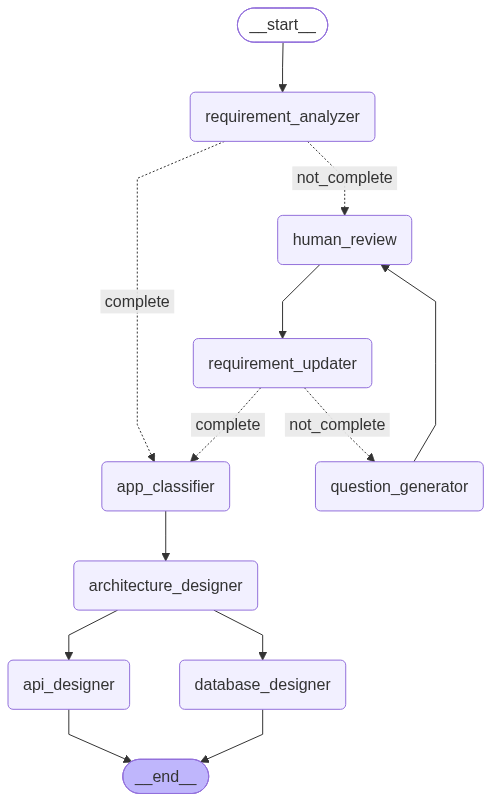

In [23]:
from langgraph.graph import StateGraph, END, START
from langgraph.checkpoint.memory import InMemorySaver

config = {
    "configurable":{
        "thread_id": "requirements_analysis_1",
    }
}

graph_builder = StateGraph(grpah_state)

graph_builder.add_node("requirement_analyzer", requirement_analyzer)
graph_builder.add_node("human_review", human_review)
graph_builder.add_node("requirement_updater", requirement_updater)
graph_builder.add_node("question_generator", question_generator)
graph_builder.add_node("app_classifier", app_classifier)    
graph_builder.add_node("architecture_designer", architecture_designer)  
graph_builder.add_node("database_designer", database_designer)
graph_builder.add_node("api_designer", api_designer)

graph_builder.add_edge(START, 'requirement_analyzer')
graph_builder.add_conditional_edges(
    "requirement_analyzer",
    requirement_router,
    {
        "complete": "app_classifier",
        "not_complete": "human_review"
    }
)
graph_builder.add_edge("question_generator", "human_review")
graph_builder.add_edge("human_review", 'requirement_updater')
graph_builder.add_conditional_edges(
    "requirement_updater",
    requirement_router,
    {
        "complete": "app_classifier",
        "not_complete": "question_generator"
    }
)
graph_builder.add_edge("app_classifier", "architecture_designer")
graph_builder.add_edge("architecture_designer", "database_designer")
graph_builder.add_edge("architecture_designer", "api_designer")
graph_builder.add_edge("api_designer", END)
graph_builder.add_edge("database_designer", END)
memory = InMemorySaver()


graph = graph_builder.compile(checkpointer=memory)

graph

In [26]:
import time
results = graph.invoke({"user_idea" : "I wanted to build a e-commerce website where users can browse the products and add to carts and will buy product by payemtns usnig UPI, COD, Credit cards also like wise we need full stack application.",
                "requirements" : "", "human_response" : "", "current_question" : ""},
                config = config
    )

while "__interrupt__" in results:
    question = results["__interrupt__"][0].value["message"]
    print(f"Missing information: {question}")
    answer = input("Please provide the missing information: ")
    time.sleep(40)  
    results = graph.invoke(
        Command(resume = answer),
        config = config
    )

print("Final Results:")
print(results)

Missing information: 
Missing information: Which payment gateway(s) would you like to use for UPI and credit‑card processing (e.g., Razorpay, Stripe, Paytm, etc.)?
Missing information: Could you let me know what kind of shipping/delivery integration you need—like flat‑rate shipping, a third‑party courier API, or multiple shipping zones?
Missing information: Do you want the e‑commerce solution to be a responsive web app only, or also include a native mobile app?
Missing information: Would you like to include social login options (Google, Facebook, or Apple) alongside the standard email/password registration?


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-120b` in organization `org_01kw2fp2f2fcksr3w91c9sk84t` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Used 4496, Requested 4459. Please try again in 7.1625s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}